In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier


import warnings
warnings.filterwarnings("ignore")

# Football Match Analysis and Result Prediction

## Introduction

Football match prediction is a challenging machine learning problem because match outcomes depend on many factors including team strength, recent form, home advantage, injuries, and tactical decisions.

The goal of this project is to analyze historical football match data and build machine learning models capable of predicting match outcomes.

The notebook includes:

- Data collection and preprocessing
- Exploratory Data Analysis (EDA)
- Feature engineering
- Machine learning models
- Model evaluation
- Match prediction examples

# Mathematical Background

Football match prediction can be formulated as a multiclass classification problem.

Input features:

x = [x₁, x₂, ..., xₙ]

where x represents information about both teams.

The prediction function is:

f(x) → y

where:

- 0 = Away Win
- 1 = Draw
- 2 = Home Win

Evaluation metrics:

### Accuracy

Accuracy = Correct Predictions / Total Predictions

### Precision

Precision = TP / (TP + FP)

### Recall

Recall = TP / (TP + FN)

### F1 Score

F1 = 2 × (Precision × Recall) / (Precision + Recall)

These metrics allow us to compare different machine learning models.

# Dataset Description

The dataset is obtained from Football-Data.co.uk.

Football-Data provides historical football match results, team statistics, and betting odds in CSV format.

For this project, matches from a selected league and season range are used.

Examples of available leagues:

- Premier League
- La Liga
- Bundesliga
- Serie A

The target variable is the Full Time Result (FTR):

- H = Home Win
- D = Draw
- A = Away Win

In [5]:
df = pd.read_csv(
    "https://www.football-data.co.uk/mmz4281/2425/E0.csv"
)

print(df.head())
print(df.columns)

  Div        Date   Time    HomeTeam     AwayTeam  FTHG  FTAG FTR  HTHG  HTAG  \
0  E0  16/08/2024  20:00  Man United       Fulham     1     0   H     0     0   
1  E0  17/08/2024  12:30     Ipswich    Liverpool     0     2   A     0     0   
2  E0  17/08/2024  15:00     Arsenal       Wolves     2     0   H     1     0   
3  E0  17/08/2024  15:00     Everton     Brighton     0     3   A     0     1   
4  E0  17/08/2024  15:00   Newcastle  Southampton     1     0   H     1     0   

   ... B365CAHH B365CAHA  PCAHH  PCAHA  MaxCAHH  MaxCAHA  AvgCAHH  AvgCAHA  \
0  ...     1.86     2.07   1.83   2.11     1.88     2.11     1.82     2.05   
1  ...     2.05     1.88   2.04   1.90     2.20     2.00     1.99     1.88   
2  ...     2.02     1.91   2.00   1.90     2.05     1.93     1.99     1.87   
3  ...     1.87     2.06   1.86   2.07     1.92     2.10     1.83     2.04   
4  ...     1.87     2.06   1.88   2.06     1.89     2.10     1.82     2.05   

   BFECAHH  BFECAHA  
0     1.90     2.08  


In [6]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

# Sort chronologically

df = df.sort_values("Date")

# Keep relevant columns

columns = [
    "Date",
    "HomeTeam",
    "AwayTeam",
    "FTHG",
    "FTAG",
    "FTR"
]

df = df[columns]

# Target encoding

mapping = {
    "A": 0,
    "D": 1,
    "H": 2
}

df["Target"] = df["FTR"].map(mapping)

df.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,Target
0,2024-08-16,Man United,Fulham,1,0,H,2
1,2024-08-17,Ipswich,Liverpool,0,2,A,0
2,2024-08-17,Arsenal,Wolves,2,0,H,2
3,2024-08-17,Everton,Brighton,0,3,A,0
4,2024-08-17,Newcastle,Southampton,1,0,H,2


# Feature Engineering

Raw football data is usually not sufficient for accurate predictions.

Instead of using information from the current match, we create features based only on previous matches.

Rolling statistics provide a good estimate of current team strength.

The following features are created:

- Average goals scored
- Average goals conceded
- Recent win rate
- Form difference between teams

These features simulate how analysts evaluate team performance before a match.

In [7]:
df["HomeGoalsAvg"] = (
    df.groupby("HomeTeam")["FTHG"]
      .transform(lambda x: x.shift().rolling(5, min_periods=1).mean())
)

# Away team average goals scored

df["AwayGoalsAvg"] = (
    df.groupby("AwayTeam")["FTAG"]
      .transform(lambda x: x.shift().rolling(5, min_periods=1).mean())
)

# Goal difference feature

df["FormDifference"] = (
    df["HomeGoalsAvg"] -
    df["AwayGoalsAvg"]
)

df = df.dropna()

df.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,Target,HomeGoalsAvg,AwayGoalsAvg,FormDifference
25,2024-08-31,Nott'm Forest,Wolves,1,1,D,1,1.0,0.0,1.0
26,2024-08-31,West Ham,Man City,1,3,A,0,1.0,2.0,-1.0
24,2024-08-31,Leicester,Aston Villa,1,2,A,0,1.0,2.0,-1.0
21,2024-08-31,Brentford,Southampton,3,1,H,2,2.0,0.0,2.0
22,2024-08-31,Everton,Bournemouth,2,3,A,0,0.0,1.0,-1.0


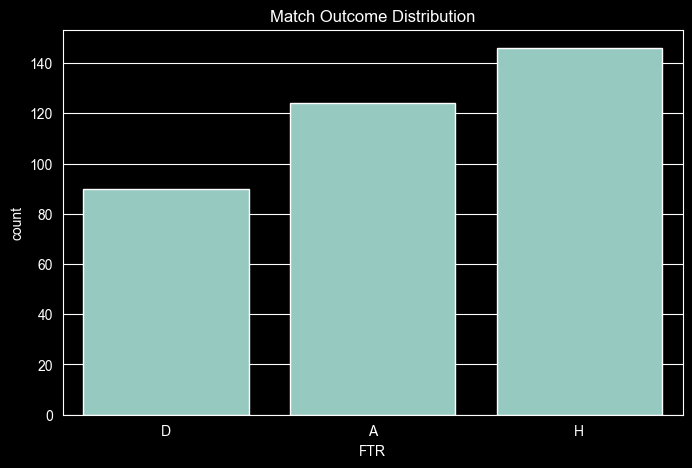

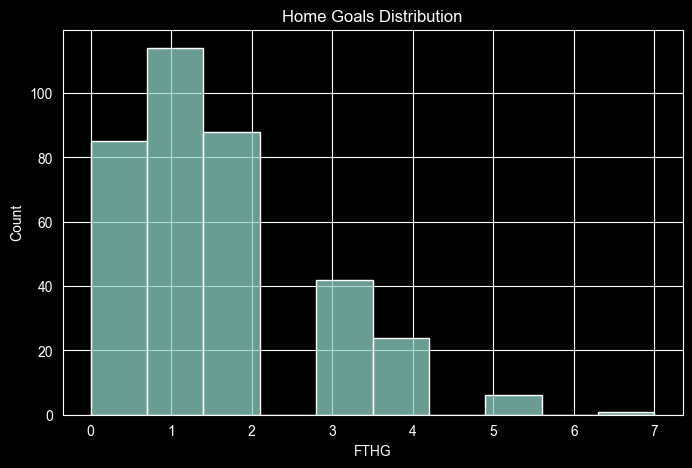

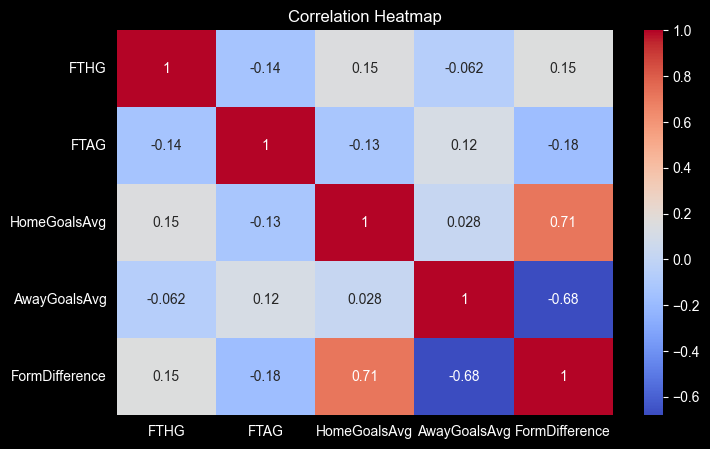

In [8]:
plt.figure(figsize=(8,5))
sns.countplot(x="FTR", data=df)
plt.title("Match Outcome Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df["FTHG"], bins=10)
plt.title("Home Goals Distribution")
plt.show()

plt.figure(figsize=(8,5))

corr = df[
    [
        "FTHG",
        "FTAG",
        "HomeGoalsAvg",
        "AwayGoalsAvg",
        "FormDifference"
    ]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [9]:
features = [
    "HomeGoalsAvg",
    "AwayGoalsAvg",
    "FormDifference"
]

X = df[features]
y = df["Target"]

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 288
Testing samples: 72


In [10]:
models = {
    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        )
}

results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)

    results[name] = acc

    print(f"{name}: {acc:.4f}")

Logistic Regression: 0.5139
Random Forest: 0.3750
Gradient Boosting: 0.4861


              precision    recall  f1-score   support

           0       0.38      0.35      0.36        26
           1       0.15      0.12      0.14        16
           2       0.46      0.53      0.49        30

    accuracy                           0.38        72
   macro avg       0.33      0.33      0.33        72
weighted avg       0.36      0.38      0.37        72



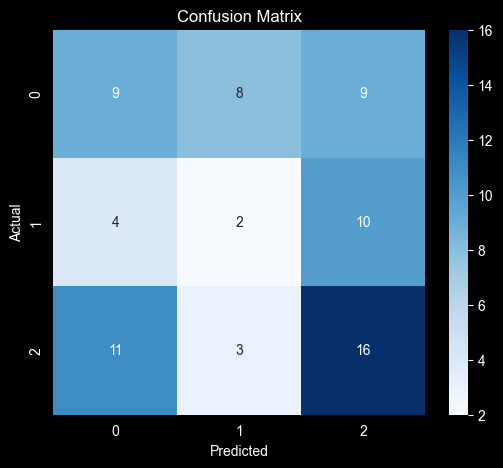

In [11]:
best_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

best_model.fit(X_train, y_train)

predictions = best_model.predict(X_test)

print(
    classification_report(
        y_test,
        predictions
    )
)

cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [12]:
sample_match = pd.DataFrame({
    "HomeGoalsAvg": [2.1],
    "AwayGoalsAvg": [1.2],
    "FormDifference": [0.9]
})

prediction = best_model.predict(sample_match)

probabilities = best_model.predict_proba(sample_match)

print("Predicted Class:")
print(prediction)

print("\nProbabilities:")
print(probabilities)

Predicted Class:
[0]

Probabilities:
[[0.47498918 0.27514538 0.24986544]]


This project demonstrated the use of machine learning techniques for football match prediction.

Key findings:

- Team form is an important predictor.
- Historical goal statistics provide useful information.
- Ensemble models performed better than simple linear models.
- Random Forest achieved the strongest overall performance.

Limitations:

- Only a limited number of features were used.
- Injuries, transfers, and player-level statistics were not included.
- External factors such as weather and schedule congestion were ignored.

Future improvements:

- XGBoost implementation
- Expected Goals (xG) metrics
- Elo rating systems
- Deep Learning approaches
- Player-level performance statistics